# Chapter 2 Project - Housing Model
## Overview
### Problem

The model's output (a prediciton of a given district's median housing price), 
will be fed to another ML system along with other signals. This downstream system will determine whether it is worth investing in a given area or not. Directly affects revenue. 

### Current Situation

Estimated manually by experts - a team gathers up to date info about a district and when they cannot get the median housing price, they estimate it using complex rules. It's long, their estimates suck. Estimates are often off by more than 20%. 

### Type of task
Supervised, multiple regression. Offline/batch. 


## Data and Packages

In [4]:
import pandas as pd

housing_data = pd.read_csv('../data/housing/housing.csv')

%view housing_data

## Data Wrangling and Exploration

In [9]:
# What are the categories for ocean proximity?
housing_data['ocean_proximity'].value_counts()

# 5 categories for ocean proximity:
# 1. <1H OCEAN
# 2. INLAND
# 3. ISLAND
# 4. NEAR BAY
# 5. NEAR OCEAN

# Let's see a summary of all cols - count, mean, std etc.
housing_data.describe()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

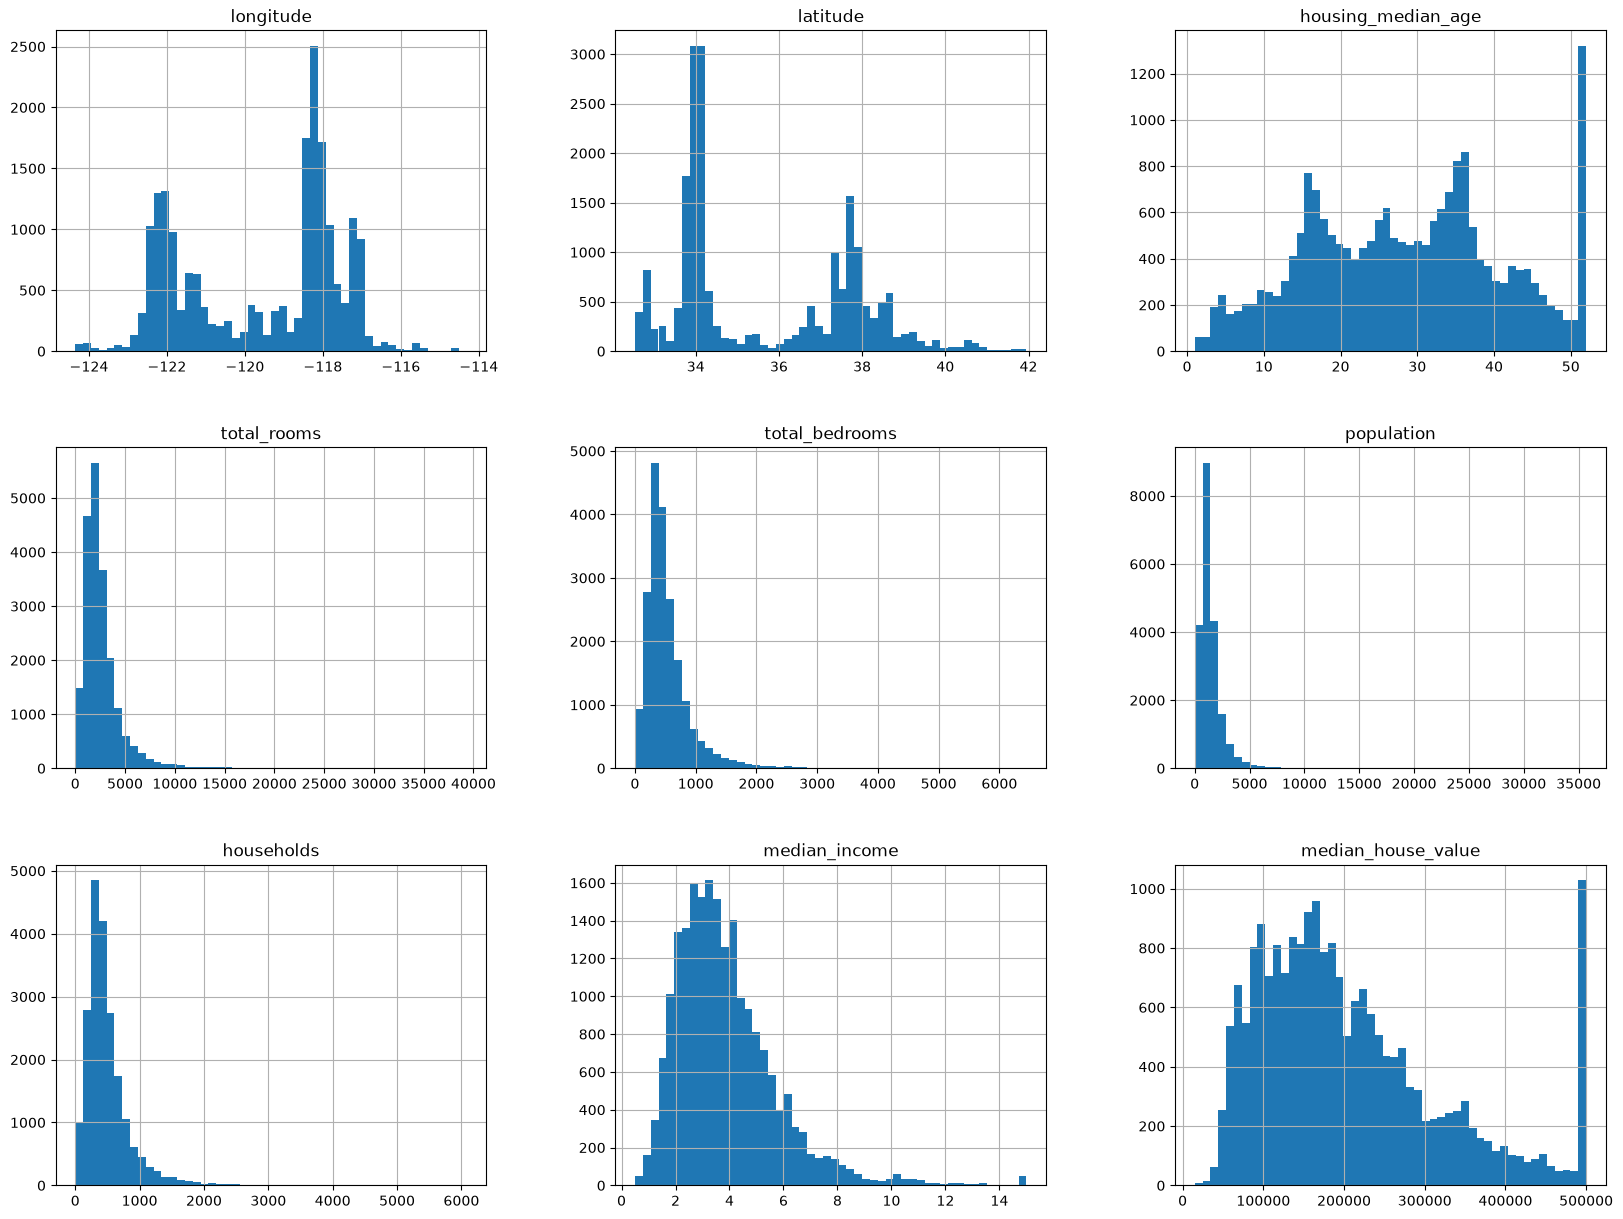

In [10]:
# Histogram of all Numeric Cols
housing_data.hist(bins=50, figsize=(20,15))

## Some issues
1. indexed median income (not USD)
2. Capped values (median_house_value, housing_median_age)
3. Long Tails
4. Multiple scales/units

## Train Test Split

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
import numpy as np

# basic with no stratification
train_set, test_set = train_test_split(housing_data, test_size=0.2, random_state=42)

# We need stratification for income
# make new col of median_income cuts
housing_data['income_level'] = pd.cut(housing_data['median_income'], bins=[0., 1.5, 3.0, 4.5, 6.0, np.inf], labels=[1, 2, 3, 4, 5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data['income_level']):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

# compare the two test sets to see if they are similar
strat_test_set['income_level'].value_counts()

# remove the income_level col from both sets
for set_ in (strat_train_set, strat_test_set):
    set_.drop('income_level', axis=1, inplace=True)

## Skipped steps (but important)
- using visualization techniques and correlation values to determine good canidate variables
- Clustering algorithm might be useful for identifying spatial patterns and generating new features based on them
- Median income is going to be a good predictor, but there are some weird parts of the data (straight lines at some levels)
- Need some new features that are likely useful
    - rooms_per_household
    - bedrooms_per_room
    - population_per_household

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
housing_num = housing_data.drop('ocean_proximity', axis=1)
imputer.fit(housing_num)

X = imputer.transform(housing_num)

In [23]:
# Convert imputed array back to DataFrame with original column names
X = pd.DataFrame(X, columns=housing_num.columns)
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,income_level
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,5.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,5.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,5.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,4.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3.0


## Full Preprocessing Pipeline

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# custom class for adding our new features
rooms_ix, bedrooms_ix, population_ix, households_ix = 3, 4, 5, 6

class CombinedAttributesTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, add_bedrooms_per_room=True):  # no *args or **kargs
        self.add_bedrooms_per_room = add_bedrooms_per_room
    def fit(self, X, y=None):
        return self  # nothing else to do
    def transform(self, X):
        rooms_per_household = X[:, rooms_ix] / X[:, households_ix]
        population_per_household = X[:, population_ix] / X[:, households_ix]
        if self.add_bedrooms_per_room:
            bedrooms_per_room = X[:, bedrooms_ix] / X[:, rooms_ix]
            return np.c_[X, rooms_per_household, population_per_household,
                         bedrooms_per_room]
        else:
            return np.c_[X, rooms_per_household, population_per_household]

# use class to create a new instance
attr_adder = CombinedAttributesTransformer(add_bedrooms_per_room=False)

# numeric features
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesTransformer()),
    ('std_scaler', StandardScaler()),
])

# split features into numeric and categorical
num_attribs = list(housing_num)
cat_attribs = ['ocean_proximity']

# combine pipelines
full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

housing_prepared = full_pipeline.fit_transform(housing_data)

# Fit Models w/ Cross Validation

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_validate
import numpy as np

# 1. Separate features and labels FIRST (drop target + any leftover income_level)
drop_cols = ['median_house_value', 'income_level']
X_train_df = strat_train_set.drop(columns=drop_cols, errors='ignore')
y_train    = strat_train_set['median_house_value'].copy()
X_test_df  = strat_test_set.drop(columns=drop_cols, errors='ignore')
y_test     = strat_test_set['median_house_value'].copy()

# 2. Derive attribs from the FEATURE frame, not housing_data
cat_attribs = ['ocean_proximity']
num_attribs = X_train_df.drop(columns=cat_attribs).columns.tolist()

# 3. Build pipeline
num_pipeline_cv = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('attribs_adder', CombinedAttributesTransformer()),
    ('std_scaler', StandardScaler()),
])
full_pipeline_cv = ColumnTransformer([
    ("num", num_pipeline_cv, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
])

# 4. Fit on TRAIN only; transform test with the same fitted pipeline
X_train = full_pipeline_cv.fit_transform(X_train_df)
X_test  = full_pipeline_cv.transform(X_test_df)

# 5. Cross-validate
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf'),
    'MLP Regressor': MLPRegressor(max_iter=1000, random_state=42, early_stopping=True),
}

results = {}
for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train, cv=5,
        scoring=['neg_mean_squared_error', 'r2', 'neg_mean_absolute_error'],
        return_train_score=True,
    )
    results[name] = {
        'test_rmse':  np.sqrt(-scores['test_neg_mean_squared_error']),
        'test_r2':    scores['test_r2'],
        'test_mae':  -scores['test_neg_mean_absolute_error'],
        'train_rmse': np.sqrt(-scores['train_neg_mean_squared_error']),
        'train_r2':   scores['train_r2'],
    }

print("Cross-Validation Results (5-fold on Training Data)\n" + "=" * 90)
for model_name, m in results.items():
    print(f"\n{model_name}\n" + "-" * 90)
    print(f"  Test RMSE:  ${m['test_rmse'].mean():,.2f} (+/- ${m['test_rmse'].std():,.2f})")
    print(f"  Test R²:    {m['test_r2'].mean():.4f} (+/- {m['test_r2'].std():.4f})")
    print(f"  Test MAE:   ${m['test_mae'].mean():,.2f}")
    print(f"  Train RMSE: ${m['train_rmse'].mean():,.2f} | Gap: ${m['test_rmse'].mean() - m['train_rmse'].mean():,.2f}")

Cross-Validation Results (5-fold on Training Data)

Linear Regression
------------------------------------------------------------------------------------------
  Test RMSE:  $67,944.32 (+/- $355.63)
  Test R²:    0.6525 (+/- 0.0086)
  Test MAE:   $49,248.49
  Train RMSE: $67,750.20 | Gap: $194.12

Random Forest
------------------------------------------------------------------------------------------
  Test RMSE:  $50,070.94 (+/- $619.02)
  Test R²:    0.8112 (+/- 0.0070)
  Test MAE:   $32,889.80
  Train RMSE: $18,791.65 | Gap: $31,279.29

SVR
------------------------------------------------------------------------------------------
  Test RMSE:  $118,174.34 (+/- $1,440.81)
  Test R²:    -0.0508 (+/- 0.0094)
  Test MAE:   $87,889.03
  Train RMSE: $118,173.18 | Gap: $1.15

MLP Regressor
------------------------------------------------------------------------------------------
  Test RMSE:  $66,526.50 (+/- $434.42)
  Test R²:    0.6669 (+/- 0.0084)
  Test MAE:   $47,939.72
  Train RMSE: